# Lipai Huang 630003919

# Project Checkpoint 2: Research Question Formation

Github repo: https://github.com/WSpie/CSCE676_proj

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 120

RANDOM_SEED = 42

d:\Coding\Anaconda3\envs\py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Collaboration Declaration

1) Collaborators:
- None.

2) Web Sources:
- Hugging Face Datasets pages:
  - Yelp Review Full: https://huggingface.co/datasets/Yelp/yelp_review_full

3) AI Tools:
- ChatGPT (used for code scaffolding and writing help).

4) Paper / Method Citations:
- Zhang, X., Zhao, J. and LeCun, Y., 2015. Character-level convolutional networks for text classification. Advances in neural information processing systems, 28.
- Blei, D.M., Ng, A.Y. and Jordan, M.I., 2003. Latent Dirichlet Allocation. Journal of Machine Learning Research, 3, pp.993-1022.

## 1. Project scope and short recap

For this project I use the Yelp Review Full dataset from Hugging Face.  
This is a 5-class text classification problem where the input is review text and the target is the Yelp star label.

In checkpoint 1, I found a few simple patterns from EDA:
- the dataset is balanced across the 5 labels
- review length has a long tail
- lower-rating reviews are often longer
- a simple TF-IDF + logistic regression baseline can work, but the middle ratings are harder than the extreme ratings

So in this checkpoint, I want to turn these early observations into clearer research questions.  
I will also do a little more EDA and a few small trial runs to make sure the questions are feasible.

In [2]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f) or {}

ds = load_dataset(
    "Yelp/yelp_review_full",
    token=os.getenv("HF_TOKEN") if os.getenv("HF_TOKEN") else None
)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("columns:", train_df.columns.tolist())

train shape: (650000, 2)
test shape: (50000, 2)
columns: ['label', 'text']


In [3]:
train_df["text_clean"] = train_df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
test_df["text_clean"] = test_df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

train_df["n_chars"] = train_df["text_clean"].str.len()
train_df["n_words"] = train_df["text_clean"].str.count(r"\S+")

In [4]:
print("missing text rate:", train_df["text"].isna().mean())
print("missing label rate:", train_df["label"].isna().mean())

missing text rate: 0.0
missing label rate: 0.0


In [6]:
train_df["label"].value_counts().sort_index()

label
0    130000
1    130000
2    130000
3    130000
4    130000
Name: count, dtype: int64

In [7]:
train_df[["n_words", "n_chars"]].describe()

,n_words,n_chars
count,650000.000000,650000.000000
mean,134.098089,729.681512
std,121.396115,661.357929
min,1.000000,1.000000
25%,52.000000,286.000000
50%,99.000000,537.000000
75%,175.000000,954.000000
max,1052.000000,5637.000000


## 2. Basic data check

The dataset has no missing text and no missing labels.  
The label distribution is perfectly balanced, with 130000 reviews in each class.

Review length also shows a clear long-tail pattern.  
The median review has 99 words, but some reviews are much longer, up to 1052 words.  
This is useful for my project because it suggests that review length may affect how easy or hard the classification task is.

In [5]:
train_df["length_bucket"] = pd.qcut(
    train_df["n_words"],
    q=3,
    labels=["short", "medium", "long"]
)

In [9]:
train_df["length_bucket"].value_counts()

length_bucket
short     216990
long      216666
medium    216344
Name: count, dtype: int64

In [6]:
bucket_label_counts = pd.crosstab(train_df["length_bucket"], train_df["label"])
bucket_label_props = pd.crosstab(train_df["length_bucket"], train_df["label"], normalize="index")

bucket_label_counts

label,0,1,2,3,4
length_bucket,,,,,
short,39393,34497,38216,46286,58598
medium,41551,43845,45070,44077,41801
long,49056,51658,46714,39637,29601


In [11]:
bucket_label_props.round(3)

label,0,1,2,3,4
length_bucket,,,,,
short,0.182,0.159,0.176,0.213,0.270
medium,0.192,0.203,0.208,0.204,0.193
long,0.226,0.238,0.216,0.183,0.137


The three length groups are almost the same size, so this split is simple and fair for comparison.

There is also a clear pattern between review length and label.  
Short reviews contain more 4-star reviews, while long reviews contain more 0-star and 1-star reviews.  
This makes RQ1 reasonable, because review length may be related to rating prediction difficulty.

In [7]:
train_df["text_clean2"] = train_df["text_clean"].str.lower().str.replace("&nbsp;", " ", regex=False)
test_df["text_clean2"] = test_df["text_clean"].str.lower().str.replace("&nbsp;", " ", regex=False)

In [8]:
N = 20000
train_small = train_df.sample(n=N, random_state=RANDOM_SEED)

y_train = train_small["label"].values
y_test = test_df["label"].values

cv = CountVectorizer(max_features=20000, min_df=5, stop_words="english")
X_train_count = cv.fit_transform(train_small["text_clean2"])
X_test_count = cv.transform(test_df["text_clean2"])

clf_count = LogisticRegression(max_iter=200)
clf_count.fit(X_train_count, y_train)
pred_count = clf_count.predict(X_test_count)

tfidf = TfidfVectorizer(max_features=20000, min_df=5, stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_small["text_clean2"])
X_test_tfidf = tfidf.transform(test_df["text_clean2"])

clf_tfidf = LogisticRegression(max_iter=200)
clf_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = clf_tfidf.predict(X_test_tfidf)

d:\Coding\Anaconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
pilot_results = pd.DataFrame({
    "method": ["CountVectorizer + LR", "TF-IDF + LR"],
    "accuracy": [
        accuracy_score(y_test, pred_count),
        accuracy_score(y_test, pred_tfidf)
    ],
    "macro_f1": [
        f1_score(y_test, pred_count, average="macro"),
        f1_score(y_test, pred_tfidf, average="macro")
    ]
})

pilot_results.round(4)

,method,accuracy,macro_f1
0,CountVectorizer + LR,0.4889,0.4873
1,TF-IDF + LR,0.5266,0.5232


In this small pilot test, TF-IDF performs better than CountVectorizer on both accuracy and macro F1.

This suggests that feature representation matters for this dataset, so it makes sense to compare these two methods more carefully in one research question.  
It also shows that the basic classification setup is feasible, because both models can run on a sampled training set.

In [10]:
report_count = classification_report(y_test, pred_count, output_dict=True)
report_tfidf = classification_report(y_test, pred_tfidf, output_dict=True)

In [11]:
per_class_f1 = pd.DataFrame({
    "label": [0, 1, 2, 3, 4],
    "count_f1": [report_count[str(i)]["f1-score"] for i in range(5)],
    "tfidf_f1": [report_tfidf[str(i)]["f1-score"] for i in range(5)]
})

per_class_f1.round(4)

,label,count_f1,tfidf_f1
0,0,0.6344,0.6779
1,1,0.4038,0.4376
2,2,0.3959,0.4315
3,3,0.4112,0.4424
4,4,0.5912,0.6264


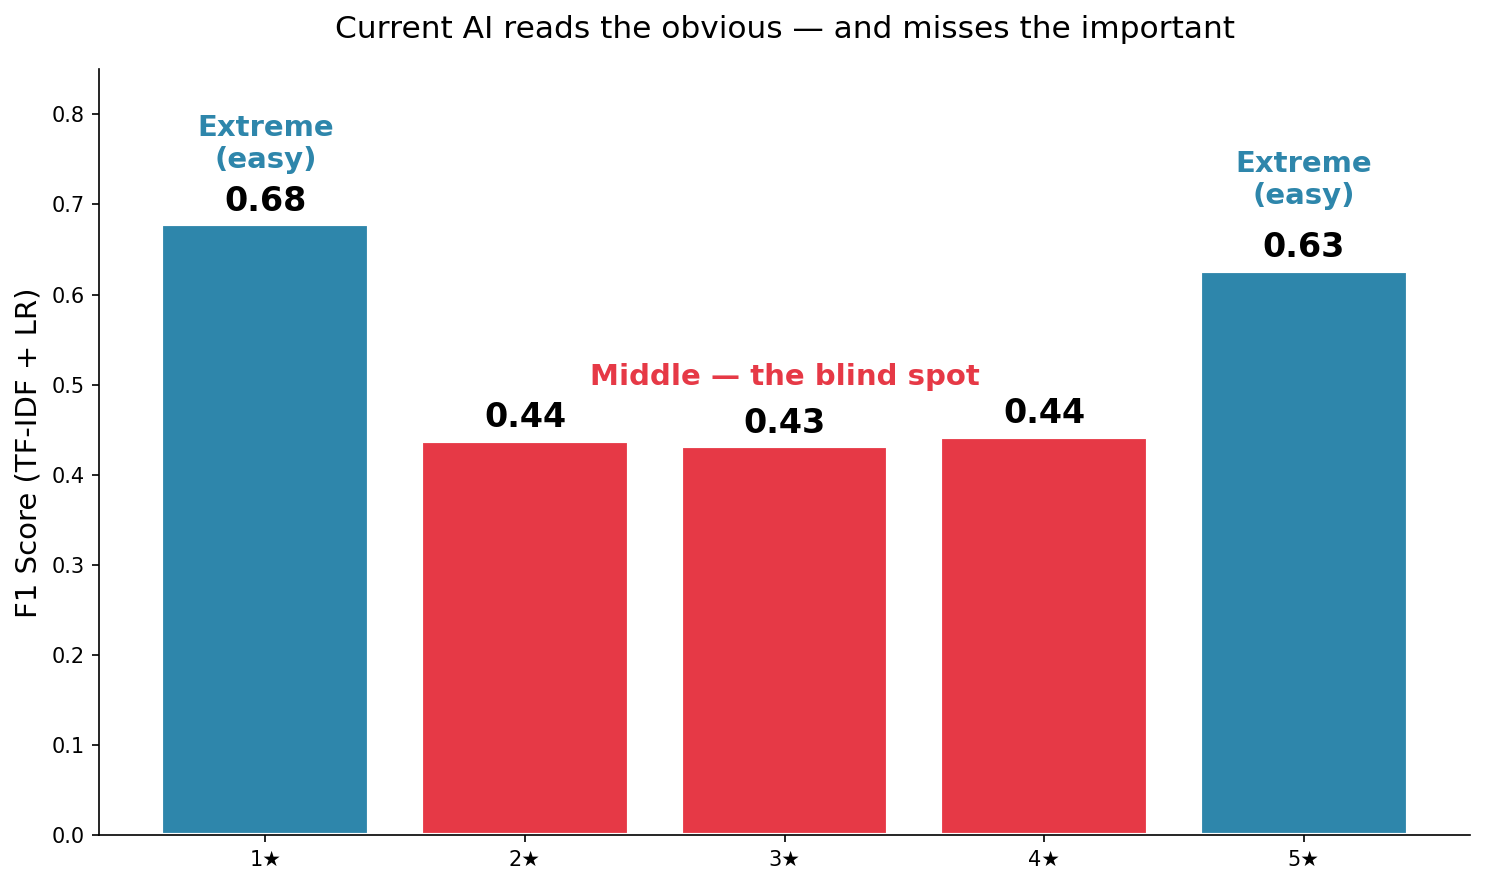

In [12]:
# ==== Slide 2: Per-class F1 — the extreme vs middle gap ====
import matplotlib.pyplot as plt
import numpy as np

star_labels = ["1★", "2★", "3★", "4★", "5★"]
f1_vals = per_class_f1["tfidf_f1"].values  # [0.6779, 0.4376, 0.4315, 0.4424, 0.6264]
colors = ["#2E86AB", "#E63946", "#E63946", "#E63946", "#2E86AB"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(star_labels, f1_vals, color=colors, edgecolor="white", linewidth=2)

for bar, v in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{v:.2f}", ha="center", fontsize=16, fontweight="bold")

ax.text(0.0, 0.74, "Extreme\n(easy)", ha="center", fontsize=14,
        color="#2E86AB", fontweight="bold")
ax.text(2.0, 0.50, "Middle — the blind spot", ha="center", fontsize=14,
        color="#E63946", fontweight="bold")
ax.text(4.0, 0.70, "Extreme\n(easy)", ha="center", fontsize=14,
        color="#2E86AB", fontweight="bold")

ax.set_ylabel("F1 Score (TF-IDF + LR)", fontsize=14)
ax.set_ylim(0, 0.85)
ax.set_title("Current AI reads the obvious — and misses the important",
             fontsize=15, pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("slide2_gap.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
summary_f1 = pd.DataFrame({
    "group": ["extreme (0,4)", "middle (1,2,3)"],
    "count_avg_f1": [
        per_class_f1.loc[per_class_f1["label"].isin([0, 4]), "count_f1"].mean(),
        per_class_f1.loc[per_class_f1["label"].isin([1, 2, 3]), "count_f1"].mean()
    ],
    "tfidf_avg_f1": [
        per_class_f1.loc[per_class_f1["label"].isin([0, 4]), "tfidf_f1"].mean(),
        per_class_f1.loc[per_class_f1["label"].isin([1, 2, 3]), "tfidf_f1"].mean()
    ]
})

summary_f1.round(4)

,group,count_avg_f1,tfidf_avg_f1
0,"extreme (0,4)",0.6128,0.6521
1,"middle (1,2,3)",0.4036,0.4372


The per-class results are also consistent with checkpoint 1.  
The extreme ratings, especially 0 and 4, have much higher F1 scores than the middle ratings 1, 2, and 3.

This means RQ2 is not only about overall accuracy.  
It is also about whether different text representations handle the middle ratings differently, since these labels seem to be the hardest part of the task.

In [14]:
N_TOPIC = 5
N_LDA_SAMPLE = 10000

lda_text = train_df["text_clean2"].sample(n=N_LDA_SAMPLE, random_state=RANDOM_SEED)

lda_cv = CountVectorizer(max_features=5000, min_df=10, stop_words="english")
X_lda = lda_cv.fit_transform(lda_text)

lda = LatentDirichletAllocation(n_components=N_TOPIC, random_state=RANDOM_SEED)
lda.fit(X_lda)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [15]:
topic_words = []
terms = lda_cv.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-10:][::-1]
    top_terms = [terms[i] for i in top_idx]
    topic_words.append([topic_idx] + top_terms)

topic_df = pd.DataFrame(
    topic_words,
    columns=["topic", "word1", "word2", "word3", "word4", "word5", "word6", "word7", "word8", "word9", "word10"]
)

topic_df

,topic,word1,word2,word3,word4,word5,word6,word7,word8,word9,word10
0,0,time,service,just,told,said,did,didn,room,got,like
1,1,food,good,ordered,service,just,restaurant,like,came,place,chicken
2,2,like,just,breakfast,good,cream,sandwich,place,cheese,ice,chocolate
3,3,food,good,place,great,service,like,pizza,really,burger,ve
4,4,place,like,just,great,good,really,vegas,bar,nice,people


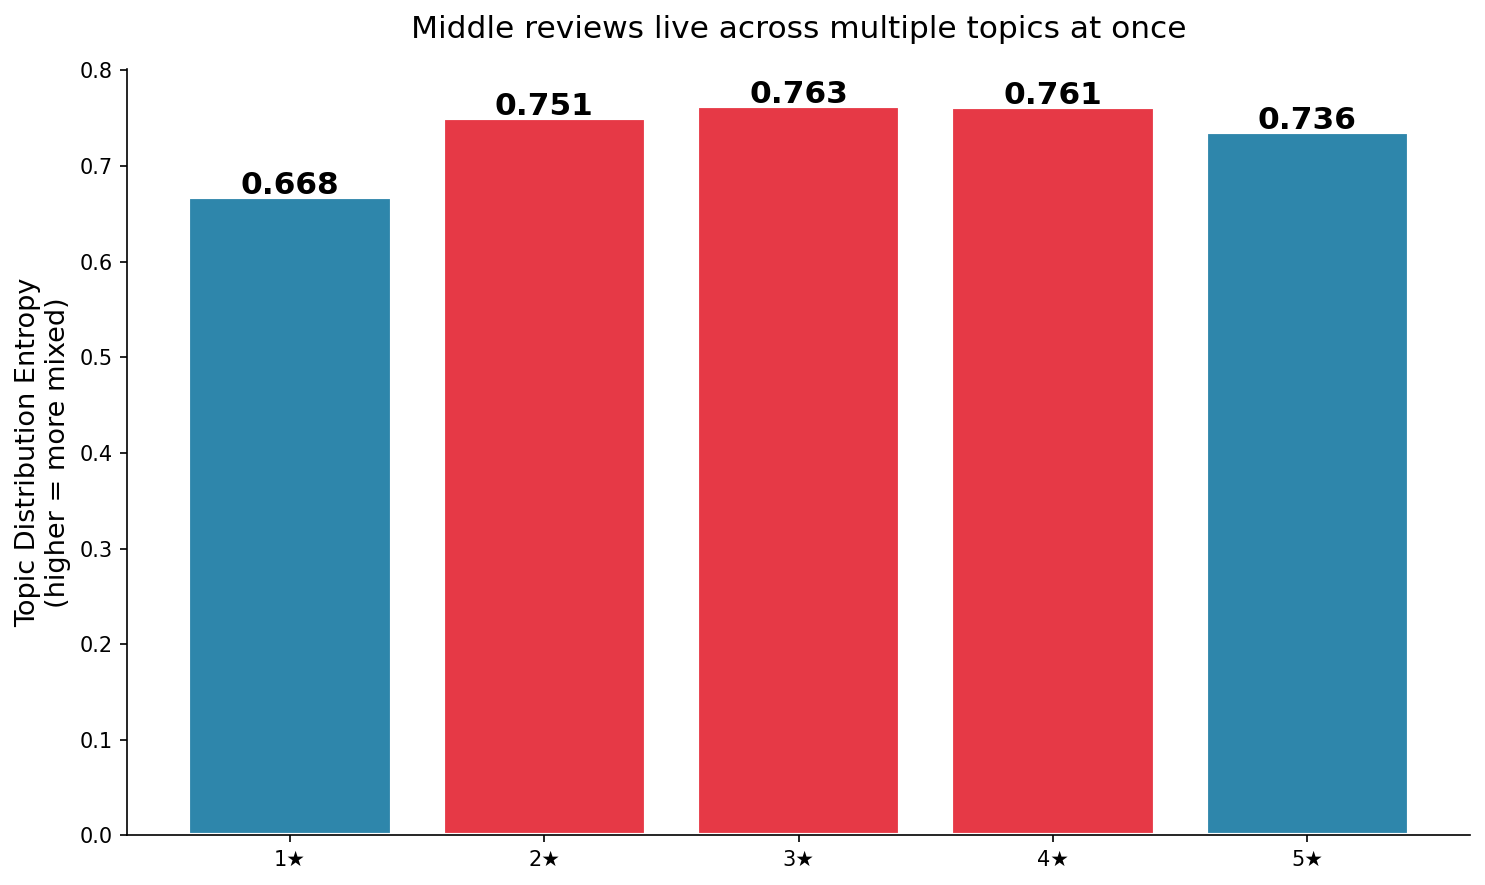

label
0    0.6676
1    0.7505
2    0.7631
3    0.7614
4    0.7358
Name: topic_entropy, dtype: float64


In [16]:
# ==== Slide 3: Are middle reviews "more mixed" in topic space? ====
from scipy.stats import entropy
import matplotlib.pyplot as plt

# 重新 sample 一批带 label 的数据，用已 fit 的 lda_cv / lda 直接 transform
sample_lab = train_df.sample(n=30000, random_state=RANDOM_SEED).copy()
X_s = lda_cv.transform(sample_lab["text_clean2"])
doc_topic = lda.transform(X_s)  # (30000, 5)

# 每条评论在 5 个 topic 上的分布熵
sample_lab["topic_entropy"] = [entropy(row) for row in doc_topic]
mean_ent = sample_lab.groupby("label")["topic_entropy"].mean()

star_labels = ["1★", "2★", "3★", "4★", "5★"]
colors = ["#2E86AB", "#E63946", "#E63946", "#E63946", "#2E86AB"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(star_labels, mean_ent.values, color=colors,
              edgecolor="white", linewidth=2)

for bar, v in zip(bars, mean_ent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{v:.3f}", ha="center", fontsize=15, fontweight="bold")

ax.set_ylabel("Topic Distribution Entropy\n(higher = more mixed)", fontsize=13)
ax.set_title("Middle reviews live across multiple topics at once",
             fontsize=15, pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("slide3_entropy.png", dpi=200, bbox_inches="tight")
plt.show()

print(mean_ent.round(4))

The LDA result is still simple, but it already shows some meaningful word groups, especially around food, service, and some business-related contexts.

The topics are not very clean yet, but this small test suggests that topic modeling is feasible on this dataset.  
So it is reasonable to use one research question about whether topic structure can show something that basic bag-of-words classification misses, especially for middle ratings.

## 3. Research question definition

### RQ1
How does review length affect rating prediction performance?

This question comes from the EDA results in checkpoint 1 and checkpoint 2.  
The review length distribution has a long tail, and the label distribution also changes across short, medium, and long reviews.

Data mining task type: text classification and subgroup analysis

Relevant algorithm(s): TF-IDF + Logistic Regression

Evaluation criteria:
- accuracy
- macro F1
- per-class F1
- comparison across length buckets

Why this question is meaningful:
If model performance changes a lot across length groups, then review length is part of the difficulty of the task.  
This can also help explain why some labels are harder than others.

### RQ2
How do CountVectorizer and TF-IDF differ for separating extreme ratings and middle ratings?

This question comes from the small pilot comparison above.  
TF-IDF already performs better than CountVectorizer in the pilot run, but both methods still seem to do much better on extreme ratings than on middle ratings.

Data mining task type: text classification and representation comparison

Relevant algorithm(s):
- CountVectorizer + Logistic Regression
- TF-IDF + Logistic Regression

Evaluation criteria:
- accuracy
- macro F1
- per-class F1
- confusion matrix
- average performance on extreme labels versus middle labels

Why this question is meaningful:
This question is not only about which method gives a higher overall score.  
It also asks whether the choice of text representation changes how well the model handles the hardest part of the dataset, which is the middle ratings.

### RQ3
Can topic modeling show some structure in middle-rating reviews that bag-of-words classification does not capture well?

This is my external method question.  
The earlier results suggest that middle ratings are harder to separate, so I want to check whether a simple topic model can show shared themes or mixed content in these reviews.

Data mining task type: topic modeling / exploratory text mining

Relevant algorithm(s):
- CountVectorizer
- Latent Dirichlet Allocation (LDA)

Evaluation criteria:
- top words in each topic
- simple topic interpretability
- whether some topics look more mixed or less clear for middle-rating reviews

Why this question is meaningful:
Bag-of-words classification focuses on prediction, but it may not explain why some reviews are harder to classify.  
A topic model may give a more interpretable view of the text structure, especially for reviews that are not clearly positive or negative.

## 4. Motivation and feasibility

These three questions are connected to the main pattern I saw in checkpoint 1.  
The main issue is that middle ratings are harder to classify than extreme ratings, and I want to study this from a few simple angles.

The project is still feasible for me because the basic text classification pipeline already runs on a sampled training set.  
The extra EDA with length buckets is also easy to do, and the small LDA test already shows that topic modeling can run on this dataset.

I think these questions are not trivial, because they are not only asking for one accuracy number.  
They also ask where the difficulty comes from, how representation affects the results, and whether an external method can show some extra structure.

There are still some risks.  
The first risk is runtime, because the full dataset is large, so I may need sampling in some experiments.  
The second risk is that LDA topics may be noisy or hard to interpret.  
Still, for this project, both risks seem manageable.

## 5. RQ-to-method mapping

| RQ | task type | method | course or external | main evaluation |
|---|---|---|---|---|
| RQ1 | text classification and subgroup analysis | TF-IDF + Logistic Regression | course | accuracy, macro F1, per-class F1, comparison across length buckets |
| RQ2 | text classification and representation comparison | CountVectorizer + Logistic Regression; TF-IDF + Logistic Regression | course | accuracy, macro F1, per-class F1, confusion matrix, extreme vs middle performance |
| RQ3 | topic modeling / exploratory text mining | CountVectorizer + LDA | external | top words per topic, simple interpretation, topic patterns for middle ratings |

## 6. Method and metric plan

For preprocessing, I will keep the text cleaning simple.  
I will mainly normalize whitespace, lowercase the text, and remove a small artifact like `&nbsp;`.  
I do not want to do too much cleaning because this is still an early student project, and I want the pipeline to stay simple.

For RQ1, I plan to use TF-IDF + Logistic Regression and compare results across short, medium, and long reviews.  
The main metrics will be accuracy, macro F1, and per-class F1.

For RQ2, I plan to compare CountVectorizer and TF-IDF using the same classifier, which is Logistic Regression.  
This makes the comparison simpler because the main difference is the text representation.  
I will look at overall scores, confusion matrices, and also compare extreme labels with middle labels.

For RQ3, I plan to use CountVectorizer with LDA topic modeling.  
The goal is not to get one final accuracy score, but to see whether the topics are interpretable and whether they help explain why middle-rating reviews are harder.

As a simple baseline, I will keep the bag-of-words classification models from the earlier cells.  
This is useful because they are easy to run and easy to compare.

## 7. Next step

In the next stage, I will run the planned methods more carefully and compare the results in a more complete way.  
The main focus will be whether review length and text representation can explain part of the difficulty for middle ratings, and whether topic modeling gives any extra insight.